# Project Commands Notebook

This notebook collects your workflow commands in clearly labeled sections.  
Cells use shell syntax where applicable. Execute them manually, adjust paths as needed, and ensure you have the right environment.

> **Note:** Cells using `%%bash` run in a POSIX shell. Windows-only commands are left as plain code blocks for reference; you may run them in **Command Prompt** or **PowerShell** instead.


## Remote connection to HPC

1. Connect to VPN
2. FileZilla to update the files
3. Remote connection with VScode
4. Create and run job
5. Download new file

### VPN

- **Server name:** `vpn.dtu.dk`

> Connect with your organization's standard VPN client before running any remote-resource steps.


### FileZilla

- **Host:** `login.hpc.dtu.dk`
- **Port:** `22`


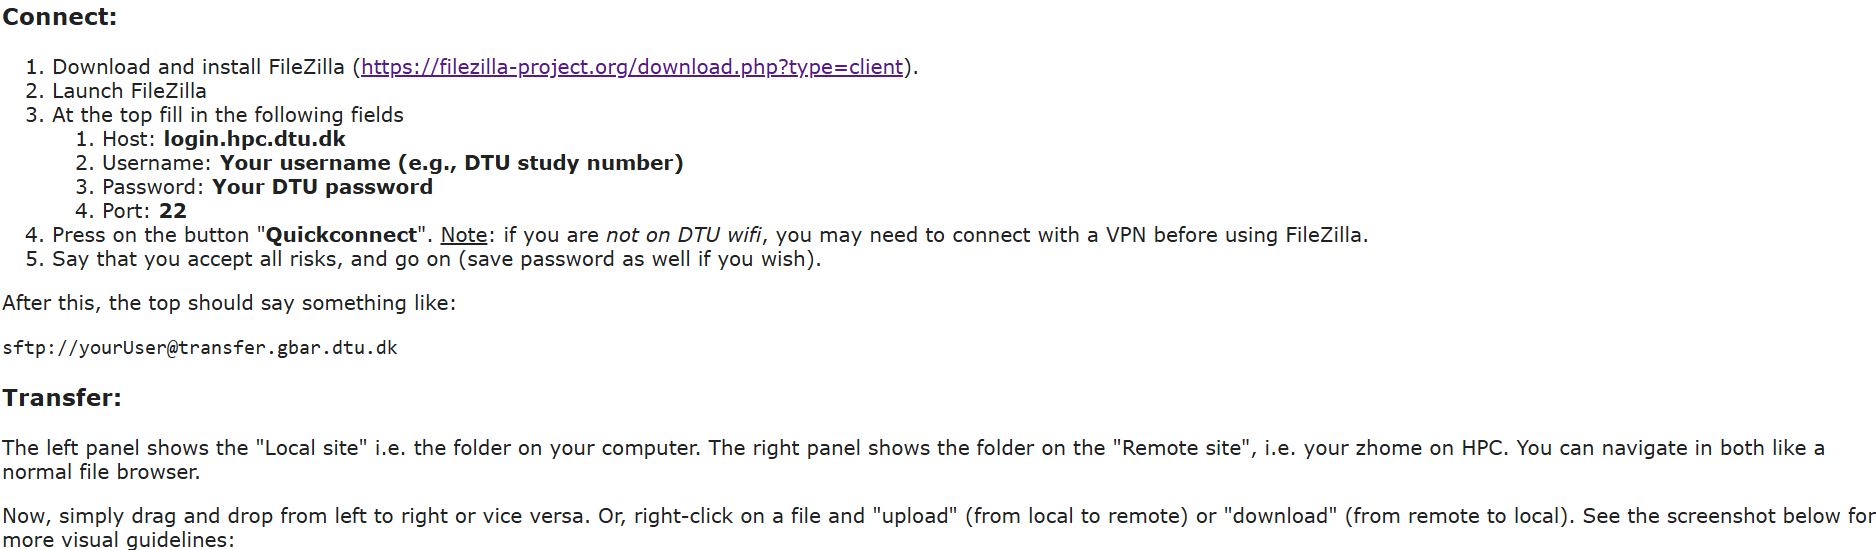

### VScode Remote Explorer

- **Host:** `login.hpc.dtu.dk`
- **Port:** `22`

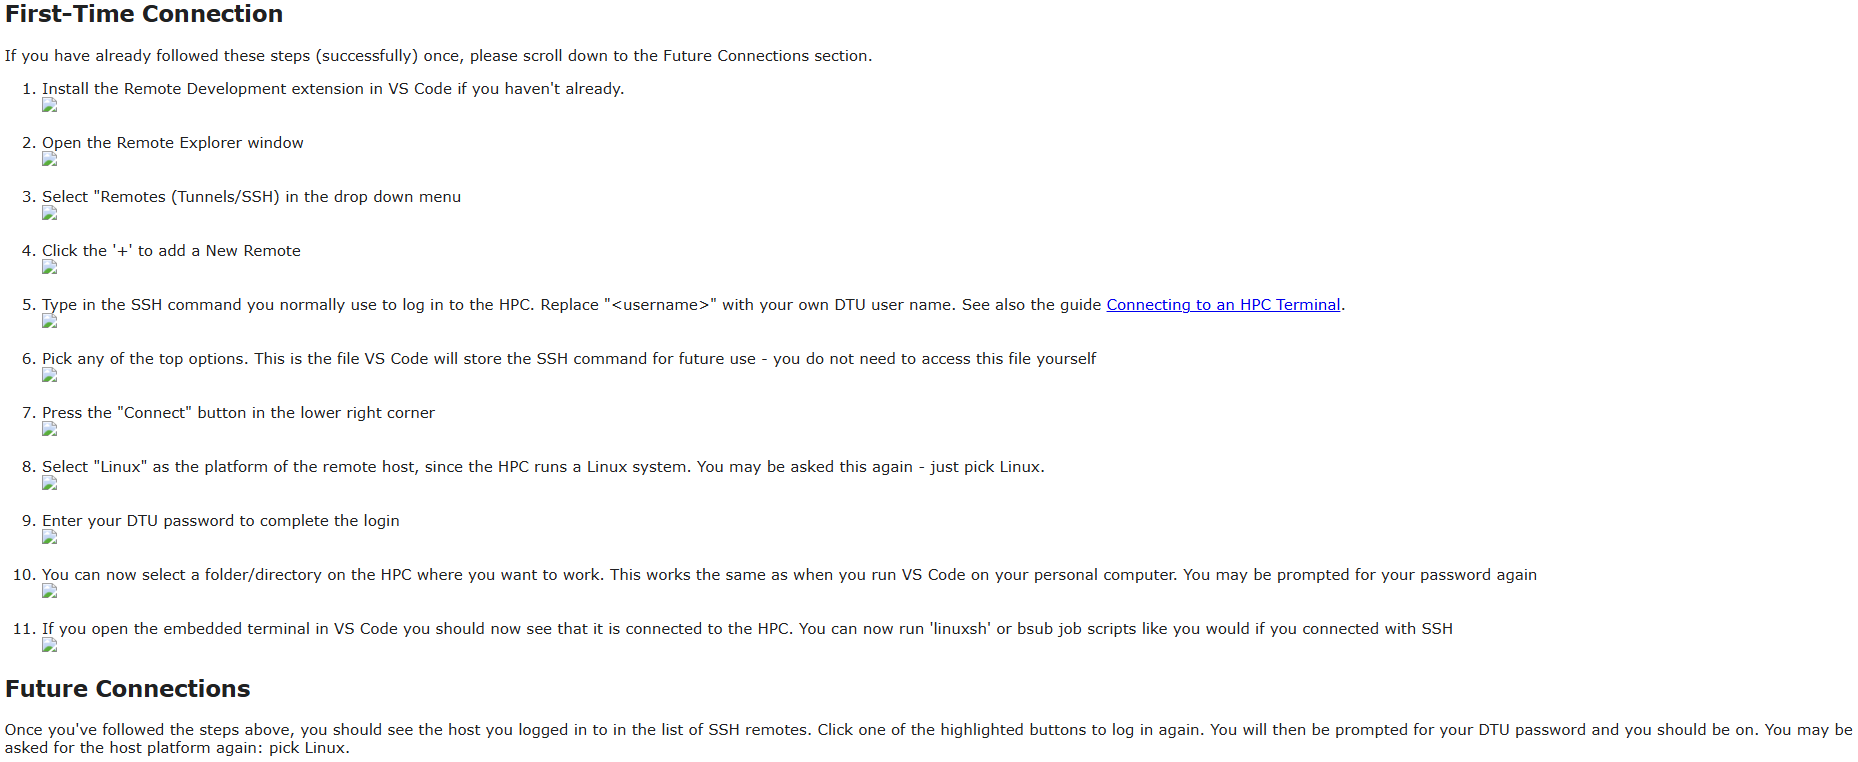

## Environment setup

The following cell shows common virtual environment activation approaches. Choose what matches your OS/shell.


In [ ]:
# --- Virtual environment activation ---
# venv\Scripts\activate.bat

# pip freeze > requirements.txt

# pip install -r requirements.txt


## Baseline decoding

In [ ]:
%%bash
# Run the baseline decoder
python src/decoding/baseline_decoder.py


## Data preparation pipeline

1. Generate synthetic data
2. Preprocess Real and Synthetic data with Gaussian filter
3. Split data into sets

### Synthetic data generation

Main generation command (adjust paths as needed). The optional `--space_dir` flag is shown in the next cell.


In [ ]:
%%bash
python data_gen_tool/scripts/gen_synth.py --dot_dir data_gen_tool/data/patches/dot --tex_dir data_gen_tool/data/textures/metal --out_dir data/n_synthetic --n 7

#   --space_dir data/patches/space


#### Generated data validation

In [ ]:
%%bash
python data_gen_tool/scripts/gen_data_val.py --img_dir data/synthetic/images/scene --label_dir data/synthetic/labels/yolo --out_dir data_gen_tool/validate


### Gaussian preprocessing

Available methods: `adaptive`, `divide`, `subtract`.


In [ ]:
%%bash
# On real images
python src/preproc/preprocess_gaussian.py --in_dir data/raw/all/images --out_dir data/preproc/check --method adaptive --debug
# On synthetic images
python src/preproc/preprocess_gaussian.py --in_dir data/synthetic/images/scene --out_dir data/preproc/synth --method divide --debug


In [ ]:
%%bash
# On retry_pre images
python src/preproc/preprocess_gaussian.py --in_dir data/raw/all/retry_pre  --out_dir data/preproc/retry_pre --method divide --debug


### Splitter (from within the data/ directory)

In [ ]:
%%bash
cd data
python data_spliter.py


## Detection, rectification and cropping

1. Train YOLO model
2. Predict with YOLO model
3. Rectify and crop using the labels from YOLO prediction

### YOLO OBB training

Adjust dataset YAML paths and model choices to your setup. Epochs/imgsz can be tuned.


In [ ]:
%%bash
# Real-only
yolo obb train data=dataset_real.yaml  model=yolo11n-obb.pt  epochs=100 imgsz=640 name=real_only_y11_obb


In [ ]:
%%bash
# Synth-only
yolo obb train data=dataset_synth.yaml model=yolo11n-obb.pt  epochs=100 imgsz=640 name=synth_only_y11_obb


In [ ]:
%%bash
# Mixed
yolo obb train data=dataset_mix.yaml   model=yolo11n-obb.pt  epochs=100 imgsz=640 name=mix_y11_obb


### YOLO prediction

In [ ]:
%%bash
# Real-only
yolo obb predict model=runs/obb/real_only_y11_obb/weights/best.pt source=data/raw/test/images save_txt=True save_conf=True


In [ ]:
%%bash
# Mixed
yolo obb predict model=models/runs/obb/train3/weights/best.pt source=data/raw/test/images save_txt=True save_conf=True

yolo segment predict model=models/runs/segment/train_inv_m/weights/best.pt source=data/raw/test/images save_txt=True save_conf=True

#### YOLO OBB validation

In [ ]:
%%bash
yolo obb val model=runs/obb/real_only_y11_obb/weights/best.pt data=dataset_real.yaml split=test imgsz=640 save=True save_txt=True save_conf=True


### Rectification of detected crops

In [ ]:
%%bash

#obb
python src/detection/rectify_crops_obb.py --img_dir data/raw/test/images --label_dir models/runs/obb/predict3/labels --out_dir data/rectified_crops_warped_obb --pad 0.1 --size 256 --debug

#segmentation
python src/detection/rectify_crops_segm_1.py --img_dir data/raw/test/images --label_dir runs/segment/predict_500_prenoaugm_100/labels --out_dir data/rectified_crops_1 --debug --square


## Upscaling crops with EDSR

Might not be necessary

In [ ]:
%%bash
python src/optimization/upscale_crops.py --input data/rectified_crops_warped_segm --output data/upscaled_crops_segm --model_path models/super_r/EDSR_x2.pb --model edsr --scale 2 --workers 4

## Dot detection and Grid fitting

In [ ]:
%%bash

python src/grid_fitting/grid_fitting_4.py --imgs data/rectified_crops_tryagain --labels runs/segment/predict_500_prenoaugm_100/labels --out data/grid_fitted_4 --debug